# DINOv3 use

Simplest possible script to load the smallest DINOv3 model (ViT-S) and run an image through it to get the global features. This is all done on the CPU.

Requires:
 - Downloading repo from GitHub (https://github.com/facebookresearch/dinov3). It is possible to call the model without downloading the repo, but I had trouble making it work due to the University firewall
  - A Python environment with the following packages:
     - PyTorch - required by model
     - transformers - for loading images, other packages like matplotlib's imread() of PIL's Image.open() can be used)
     - matplotlib - for plotting the image
  - The weights file for the DINO model (downloadable from the official DINOv3 repo)



Roughly, the steps done in the script are:
  - Importing the necessary packages
  - Loading the model
  - Defining the required image transform
  - Getting an image and applying the transform
  - Feeding the image through the model


Github repo: https://github.com/facebookresearch/dinov3

DINOv3 official blog post: https://ai.meta.com/dinov3/

(Jan 2026, Lucas Hirsch)

# Import packages

In [7]:
import torch
from torchvision.transforms import v2 #needed for dino transform
from torchvision.transforms.functional import resize
from transformers.image_utils import load_image

import matplotlib.pyplot as plt

# Load the model

Variables to set are REPO_DIR and WEIGHT_FILE_DIR

In [3]:

# Change to your directories
REPO_DIR = r"M:\projects\dinov3"
WEIGHTS_FILE = "M:\projects\dinov3_model_weights\dinov3_vits16_pretrain_lvd1689m.pth"

# ----- ViT-S ------ #
N_LAYERS = 12 # For ViTs n_layers = 12
MODEL_NAME = "dinov3_vits16"

print(f"Attempting to load {MODEL_NAME}")
model = torch.hub.load(REPO_DIR,
                        model=MODEL_NAME,
                        source='local',
                        weights=WEIGHTS_FILE,
                        trust_repo=True) # Local
print(f"{MODEL_NAME} loaded succesfully")

Attempting to load dinov3_vits16
dinov3_vits16 loaded succesfully


# Define image transform

In [9]:
# %% Transform needed for passing images through DINO
def make_transform(resize_size: int = 256):
    to_tensor = v2.ToImage()
    resize = v2.Resize((resize_size, resize_size), antialias=True)
    to_float = v2.ToDtype(torch.float32, scale=True)
    normalize = v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    )
    return v2.Compose([to_tensor, resize, to_float, normalize])

# Load an image and plot it
transformers is required for loading an image and matplotlib is required for plotting.

After the transform, the image will have negative values which will cause plt.imshow() to throw a warning. It is safe to ignore

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


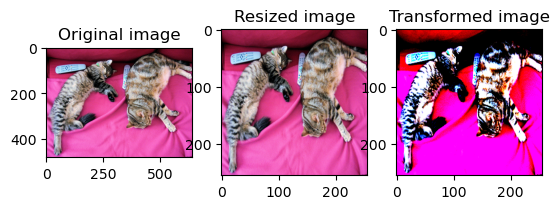

In [10]:
# %% Load image and transform
# url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
url = "http://images.cocodataset.org/val2017/000000039769.jpg"

# Resize the image
img_size_after_transform = 256
preImage = load_image(url)
preImageResize = preImage.resize((img_size_after_transform,img_size_after_transform))

# Apply DINO transform to image
transform_pipeline = make_transform(resize_size=img_size_after_transform)
image = transform_pipeline(preImageResize)

plt.figure()
plt.subplot(1,3,1)
plt.title("Original image")
plt.imshow(preImage)

plt.subplot(1,3,2)
plt.title("Resized image")
plt.imshow(preImageResize)

# This will throw an error due to the image transform
plt.subplot(1,3,3)
plt.imshow(image.permute(1, 2, 0)) #
plt.title("Transformed image")
plt.show()

# Feed image to model

First add the batch dimension and then pass it through the model. Everything is done on the cpu

In [12]:
device = 'cpu'

# Add batch dimension to image (required by model)
# Shape changes from (C, H, W) to (B, C, H, W). B=1 in this case
input_image = image.unsqueeze(0)

# Move the input tensor and the model to the target device
input_image = input_image.to(device)
model = model.to(device)

In [13]:
# Evaluate the image - GLOBAL FEATURE VECTOR
model.eval()
with torch.inference_mode():
    global_features = model(input_image)

print(f"Feature extraction complete.")
print(f"Global feature shape: {global_features.shape}")

Feature extraction complete.
Global feature shape: torch.Size([1, 384])
